<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/langgraph_tool_calling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
!pip install tavily
!pip install langchain-mistralai

In [92]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from langchain.tools import tool
from tavily import TavilyClient
import os
from typing import Annotated , TypedDict
from langgraph.prebuilt import ToolNode , tools_condition


In [93]:
TAVILY_API_KEY = "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"
OPENAPI_WEATHER_API_KEY = "b3c5d59579a90c0befc2043610f92c5e"
CHAT_MISTRAL_API_KEY = "GruWOkyO4I5ZP30nhe7IIzXbLvARh8mh"

In [94]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY
)

In [95]:
@tool
def get_weather(city : str)->str:
  """Get weather of the city """
  url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={OPENAPI_WEATHER_API_KEY}&units=metric"

  response = requests.get(url)
  data = response.json()

  if str(data.get("cod")) !="200":
      return f"ERROR  :{data.get('message','Could not fetch weather')}"

  temp  = data["main"]["temp"]
  desc = data['weather'][0]['description']
  return f"weather in {city} : {desc} , {temp} degree celcius"

In [96]:
tavily_client = TavilyClient(api_key = TAVILY_API_KEY)
@tool
def get_news(city : str) ->str:
    """Get latest news about the city"""

    response = tavily_client.search(
        query = f"latest news in {city}",
        search_depth = "basic",
        max_results = 3
    )

    results = response.get("results",[])

    if not results:
        return f"No news found for {city}"

    news_list = []

    for r in results:
        title = r.get("title" , "No title")
        url = r.get("url","")
        snippet = r.get("content","")

        news_list.append(
        f"Title: {title}\nURL: {url}\nSnippet: {snippet[:100]}..."
        )

    return f"Latest News in {city}:\n\n" + "\n\n".join(news_list)

In [97]:
llm_with_tools = llm.bind_tools([get_weather , get_news])
tools={
    "get_weather" : get_weather,
    "get_news" : get_news
}

In [98]:
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]

In [99]:
SYSTEM_PROMPT = SystemMessage(content="""You are a helpful assistant with access to two tools:
- get_weather: fetches current weather for a city
- news search tool: fetches latest news

Rules:
1. Use a tool ONLY when the user's request genuinely needs live/current data (weather, latest news). Don't call a tool for general knowledge questions.
2. When you get tool results back, present them in a clean, well-formatted, readable way (use markdown, bullet points, or tables where helpful — not a raw dump).
3. If a tool call is denied by the user, politely tell them you couldn't fetch the live data and offer to help another way.
4. Keep responses concise and directly useful.
""")

In [100]:
def chatbot(state: MessagesState):
    messages = state['messages']
    result = llm_with_tools.invoke([SYSTEM_PROMPT] + messages)

    if not result.tool_calls:
        print("BOT :", result.content)
        return {"messages": [result]}

    tool_messages = []
    denied = False

    for tool_call in result.tool_calls:
        tool_name = tool_call['name']
        confirm = input(f"Agent wants to call {tool_name} with {tool_call['args']}. Approve (y/n): ")

        if confirm.lower() == "n":
            denied = True
            tool_messages.append(ToolMessage(
                content="Tool call denied by user.",
                tool_call_id=tool_call['id']
            ))
            continue

        tool_result = tools[tool_name].invoke(tool_call)

        tool_messages.append(tool_result)

    if denied and len(tool_messages) == len(result.tool_calls) and all(
        "denied" in tm.content for tm in tool_messages
    ):
        final = AIMessage(content="Okay, I won't fetch that data. Let me know if you'd like help another way.")
        return {"messages": [final]}

    followup = llm.invoke([SYSTEM_PROMPT] +  [result] + tool_messages)

    print('*' * 100)
    print(followup.content)
    print('*' * 100)

    final_ai_message = AIMessage(content=followup.content)
    return {"messages": [result] + tool_messages + [final_ai_message]}


In [101]:
def human(state : MessagesState):
    message = input("Ask your question...\n")
    return {"messages":[HumanMessage(content=message)]}

In [102]:
def human_approval(state : MessagesState):
  if state["messages"][-1].content.lower() == "exit":
    return END
  return "chatbot"

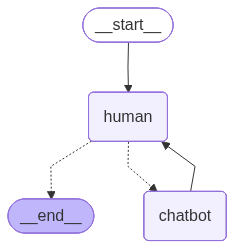

In [124]:
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
builder   = StateGraph(MessagesState)
builder.add_node("chatbot",chatbot)
builder.add_node("human",human)

builder.add_edge(START,"human")
builder.add_conditional_edges(
    "human",
    human_approval,
    {
        "chatbot": "chatbot",
        END: END,
    },
)
builder.add_edge("chatbot","human")
memory = MemorySaver()
graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [125]:
config = {"configurable": {"thread_id": "6564652185565"}, "recursion_limit": 100}
output = graph.invoke({"messages": []}, config=config)
print("\n--- Full Conversation ---\n")
for m in output["messages"]:
    print(f"{m.type.upper()}: {m.content}\n")

Ask your question...
hello


BOT : Hi there! How can I assist you today?

Ask your question...
what is weather in palampur
Agent wants to call get_weather with {'city': 'palampur'}. Approve (y/n): y


****************************************************************************************************

The current weather in Palampur is a clear sky with a temperature of 24.24°C.

...

HUMAN: news of ncr

AI:

TOOL: Latest News in ncr:

Title: Latest News, Photos, Videos on Ncr - NDTV.COM
URL: https://www.ndtv.com/topic/ncr
Snippet: Ncr Extreme Heat And Severe Air Pollution Make For A Lethal Combination, NCR Improved Quality Of Lif...

Title: Delhi NCR Region News, Latest Delhi NCR ... - The Times of India
URL: https://timesofindia.indiatimes.com/city/delhincr
Snippet: Puri-Delhi Purushottam Express train halts for over 3 hours in UP amid bomb scare · Delhi projected ...

Title: Latest News, Photos, Videos on Delhi Ncr - NDTV.COM
URL: https://www.ndtv.com/topic/delhi-ncr
Snippet: Delhi-NCR Transport Strike May Hit Fruit, Vegetable Supply For 3 Days · Hoarding Falls On Goods-Lade...

AI: Here are some of the latest news headlines from NCR (National Capital Region):

- **NDTV**: NCR faces extreme heat and severe air pollution, creating a lethal combination. The region has seen 
improvements in the quality of life.
- **The Times of India**: The Puri-Delhi Purushottam Express train was halted for over 3 hours in Uttar Pradesh due
to a bomb scare. Delhi is projected to experience a significant population increase.
- **NDTV**: A transport strike in Delhi-NCR may disrupt the supply of fruits and vegetables for three days. There 
has been a notable decrease in hoarding of goods-laden trucks.

For more details, you can visit the respective news websites.

HUMAN: exit